In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt


from kineticanalysis.generator.generator_track import (generate_tracks, generate_one_track)
from kineticanalysis.analysis.analysis_track import single_track_analysis, check_track_validity

In [2]:
path_save = "/home/u2175049/Documents/Code/KineticAnalysis/notebook/figures/"
path = "/mnt/sda1/Sophie/2-KineticAnalysisData/2-Datas/05-Modelling/01-TrackLength/"

In [3]:
prot_aa_size = {
    "32xsuntag": 796,  #768/32=24 , left 28
    "linker": 4,
    "twist": 490,
    "ilp4": 134,
    "snail": 390,
    "similar_prot":800,
    "very_long_prot":3000, 
}

In [4]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["similar_prot"]
elongation_rate = 5

In [34]:
for i in range(200):
    x_global, y_global, y_start_prot = generate_one_track(prot_length = prot_aa_size["very_long_prot"], 
                                                      suntag_length = prot_aa_size["32xsuntag"], 
                                                      nb_suntag=32, 
                                                      fluo_one_suntag=4, 
                                                      translation_rate=elongation_rate, 
                                                      binding_rate=0.05,
                                                      step = 0.1,
                                                      length=85000, 
                                                       remove_point_beginning=10000)
    if i == 0:
        datas = pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })
    else:
        datas = pd.concat([datas, 
                           pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })], ignore_index=True)

datas.to_csv(os.path.join(path, "datas_track_length_translation_rate_5_long.csv"))

In [6]:
# datas = pd.read_csv(os.path.join(path, "datas_track_length.csv"), index_col="Unnamed: 0")
datas

,FRAME,MEAN_INTENSITY_CH1,TRACK_ID
0,0.0,785.608040,0
1,0.1,786.331658,0
2,0.2,787.055276,0
3,0.3,787.778894,0
4,0.4,788.502513,0
...,...,...,...
167999995,83999.5,705.286432,199
167999996,83999.6,705.688442,199
167999997,83999.7,706.090452,199
167999998,83999.8,706.492462,199


In [5]:
datas = pd.read_csv(os.path.join(path, "datas_track_length_translation_rate_5_same.csv"), index_col="Unnamed: 0")

In [35]:
# Utiliser t comme base de la boucle
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["very_long_prot"]
first = True

for t in [10,30,50,100]:
# t = 50

    dt = t*0.1
    for length_track in [30,60,300,600,1200,1800,2700,3600]:
        print(length_track)
        
        for i in range(200):
            datas2 = datas[datas["TRACK_ID"]==i][::t][:length_track]
            datas2["FRAME"] = np.arange(length_track)
            if (len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 1) & (len(datas2) in [30,60,300,600,1200,1800,2700,3600]):
                
                (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                       i,
                                                       normalise_intensity=1,
                                                       delta_t=dt,
                                                       rtol=1e-1,
                                                       nb_missing_point=0,
                                                       )
    
                
                (x_auto, 
                 y_auto, 
                 k, c,
                 elongation_r, 
                 translation_init_r,
                 perr) = single_track_analysis(x, 
                                             y, 
                                             delta_t = dt,
                                             protein_size=prot_aa_size["very_long_prot"],
                                             suntag_size =prot_aa_size["32xsuntag"], 
                                             repetition_suntag = 32,
                                             mm=None,
                                             method="approx",
                                             simulation=True)
                if first:
                    results = pd.DataFrame({"elongation_r":elongation_r, 
                                            "init_translation_r":translation_init_r, 
                                            "dt":dt,
                                            "long_track":datas2.shape[0],
                                            "k":k,
                                            "c":c,
                                           "id":i},
                                          index=[0])
                    first = False
                
                else:
                    results = pd.concat([results, 
                                    pd.DataFrame({"elongation_r":elongation_r, 
                                                  "init_translation_r":translation_init_r, 
                                                  "dt":dt, 
                                                  "long_track":datas2.shape[0],
                                                  "k":k,
                                                    "c":c,
                                                  "id":i}, index=[0])
                                    ], ignore_index=True)
                        
results.to_csv(os.path.join(path, "result_track_length_translation_rate_5_long.csv"))

30
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125

/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:90: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,


125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32
125 32

In [81]:
t=10
dt = t*0.1
nb_point = int(60/dt)
datas[datas["TRACK_ID"]==i][::t][:nb_point]

,FRAME,MEAN_INTENSITY_CH1,TRACK_ID
419160000,0.0,2126.954774,499
419160010,1.0,2134.753769,499
419160020,2.0,2141.989950,499
419160030,3.0,2149.226131,499
419160040,4.0,2156.462312,499
419160050,5.0,2163.698492,499
419160060,6.0,2170.934673,499
419160070,7.0,2177.527638,499
419160080,8.0,2056.040201,499
419160090,9.0,2062.472362,499


In [82]:
t = 100
dt = t*0.1
nb_point = int(60/dt)
datas[datas["TRACK_ID"]==i][::t][:nb_point]

,FRAME,MEAN_INTENSITY_CH1,TRACK_ID
419160000,0.0,2126.954774,499
419160100,10.0,2068.904523,499
419160200,20.0,2133.226131,499
419160300,30.0,2079.758794,499
419160400,40.0,2162.492462,499
419160500,50.0,2109.909548,499


In [40]:
# Utiliser durée de la track comme base de la boucle
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["similar_prot"]
first = True

#[1, 5, 10, 30, 50, 60, 100] in min
# in sec
for length_track in [60, 300, 600, 800, 1200, 1500, 1800, 2200, 2500, 3000, 3600]:
    print(length_track)
    for t in [10,30,50,100, 300, 600]:
        dt = t*0.1
        nb_point = int(length_track/dt)
        print(t, nb_point)
        for i in range(200):
            datas2 = datas[datas["TRACK_ID"]==i][::t][:nb_point]
            datas2["FRAME"] = np.arange(nb_point)
            if (len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 2):
                
                (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                       i,
                                                       normalise_intensity=1,
                                                       delta_t=dt,
                                                       rtol=1e-1,
                                                       nb_missing_point=0,
                                                       )
    
                
                (x_auto, y_auto, k, c,elongation_r, translation_init_r,perr) = single_track_analysis(x, 
                                                                                                     y, 
                                                                                                     delta_t = dt,
                                                                                                     protein_size=prot_aa_size["similar_prot"],
                                                                                                     suntag_size =prot_aa_size["32xsuntag"], 
                                                                                                     repetition_suntag = 32,
                                                                                                     mm=None,
                                                                                                    # method="exact",
                                                                                                    # method="approx",
                                                                                                     method="epitope",
                                                                                                     simulation=True)
                if first:
                    results = pd.DataFrame({"elongation_r":elongation_r, 
                                            "init_translation_r":translation_init_r, 
                                            "dt":dt,
                                            "long_track":datas2.shape[0],
                                            "k":k,
                                            "c":c,
                                           "id":i},index=[0])
                    first = False
                
                else:
                    results = pd.concat([results, 
                                    pd.DataFrame({"elongation_r":elongation_r, 
                                                  "init_translation_r":translation_init_r, 
                                                  "dt":dt, 
                                                  "long_track":datas2.shape[0],
                                                  "k":k,
                                                    "c":c,
                                                  "length_track":length_track,
                                                  "nb_point":nb_point,
                                                  "id":i}, index=[0])
                                    ], ignore_index=True)
                        
results.to_csv(os.path.join(path, "result_track_length_translation_rate_5_same_epitope.csv"))

60
10 60
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
33 32
3

In [36]:
print("done")

done


In [7]:
(len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 2)

True

In [10]:
results = pd.read_csv(os.path.join(path, "result_track_length_translation_rate_5_long_approx.csv"), index_col="Unnamed: 0")

In [37]:
results.groupby(by=['dt', 'length_track'])[['elongation_r','init_translation_r', 'k', 'c', "long_track", "nb_point"]].mean()

elongation_r  init_translation_r           k          c  \
dt   length_track                                                            
1.0  60.0             61.503940           51.295717   15.523963  51.295717   
     300.0            11.699432            1.522415   78.382769   1.522415   
     600.0             6.616876            0.467118  135.343509   0.467118   
     800.0             5.447154            0.284841  164.915135   0.284841   
     1200.0            4.335038            0.144654  197.404754   0.144654   
...                         ...                 ...         ...        ...   
60.0 1800.0          192.155081            4.236919    4.410999   4.236919   
     2200.0          193.628785            4.125809    4.331028   4.125809   
     2500.0          194.243762            4.065033    4.286301   4.065033   
     3000.0          196.271216            3.967541    4.212468   3.967541   
     3600.0          198.068040            3.898344    4.153710   3.898344   

                   long_track  nb_point  
dt   length_track                        
1.0  60.0                60.0      60.0  
     300.0              300.0     300.0  
     600.0              600.0     600.0  
     800.0              800.0     800.0  
     1200.0            1200.0    1200.0  
...                       ...       ...  
60.0 1800.0              30.0      30.0  
     2200.0              36.0      36.0  
     2500.0              41.0      41.0  
     3000.0              50.0      50.0  
     3600.0              60.0      60.0  

[64 rows x 6 columns]

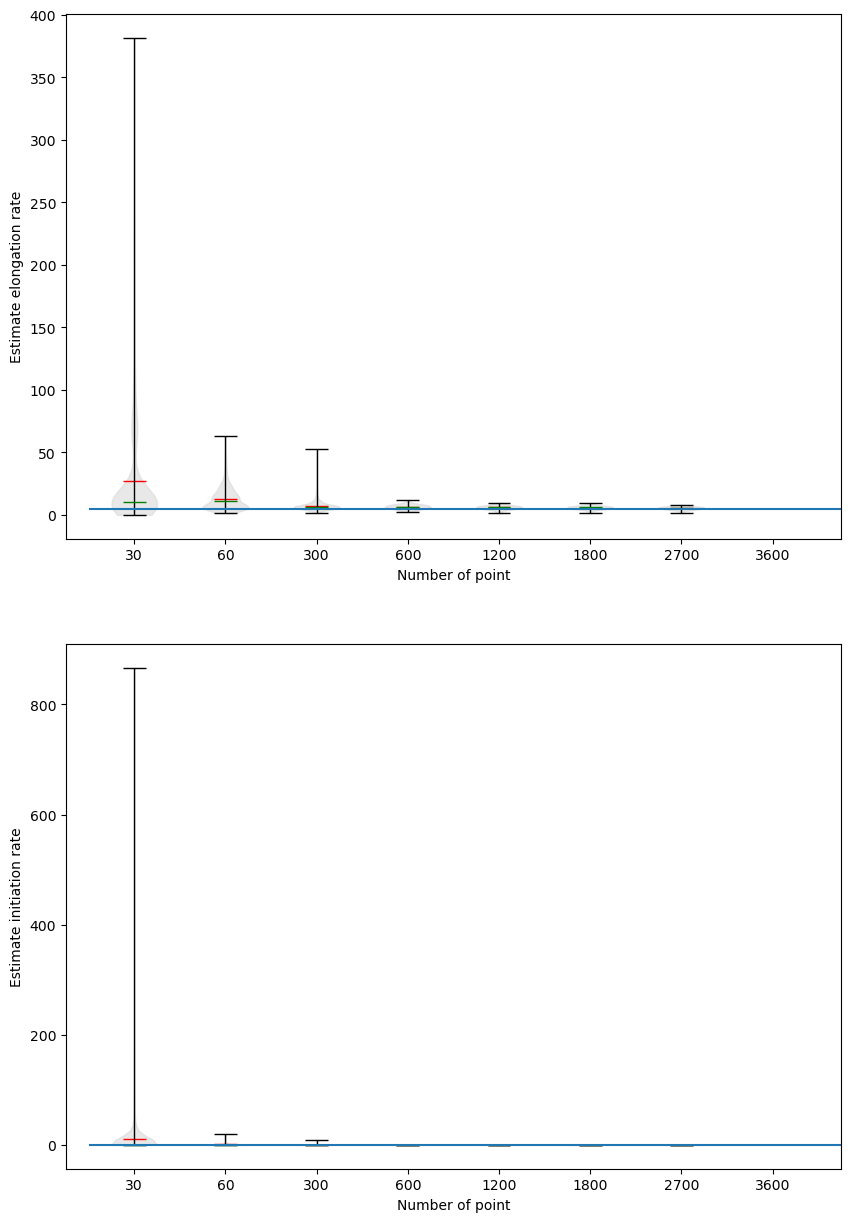

In [27]:
fig, ax = plt.subplots(2,1)


violin = ax[0].violinplot(dataset = [results[ (results.long_track == length_track)]["elongation_r"].values for length_track in [60, 300, 600, 1800, 3000, 3600, 6000]],
     showmeans=True,
      showmedians=True)

for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)
    
colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1
# results.boxplot(['init_translation_r'] , 
#                by=['dt', "long_track"], 
#                grid=False, 
#                ax = ax[1],
#                rot=90,
#                boxprops=dict(linestyle='-', linewidth=1.5, color="black"),
#                medianprops=dict(linestyle='-', linewidth=1.5, color="red"),
#                )


violin = ax[1].violinplot(dataset = [results[(results.long_track == length_track)]["init_translation_r"].values for length_track in [60, 300, 600, 1800, 3000, 3600, 6000]],
     showmeans=True,
      showmedians=True)

for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)
    
colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1

group = ['dt', "long_track"]
column = 'elongation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    if name[0] == 60:
        names.append(name)
        vals.append(subdf[column][subdf[column]>0].to_list())
        xs.append(np.random.normal(i+1-20, 0.04, subdf[column][subdf[column]>0].shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[0].scatter(x, val, c='grey', alpha=1, s=10)
    
group = ['dt', "long_track"]
column = 'init_translation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    if name[0] == 60:
        names.append(name)
        vals.append(subdf[column][subdf[column]>0].to_list())
        xs.append(np.random.normal(i+1-20, 0.04, subdf[column][subdf[column]>0].shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[1].scatter(x, val, c='grey', alpha=1, s=20)

def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('Number of point')
# set style for the axes
labels =[30,60,300,600,1200,1800,2700,3600]
for a in ax:
    set_axis_style(a, labels)

ax[0].set_ylabel("Estimate elongation rate")
ax[1].set_ylabel("Estimate initiation rate")

# ax[0].set_ylim(-5,50)
# ax[1].set_ylim(-1, 20)
ax[0].hlines(elongation_rate, 0.5, 9.5)
ax[1].hlines(0.05, 0.5, 9.5)
fig.set_size_inches((10,15))
# fig.savefig(os.path.join(path_save, "results_length_boxplot_exact_dt1_0.05_5.eps"), dpi=300)

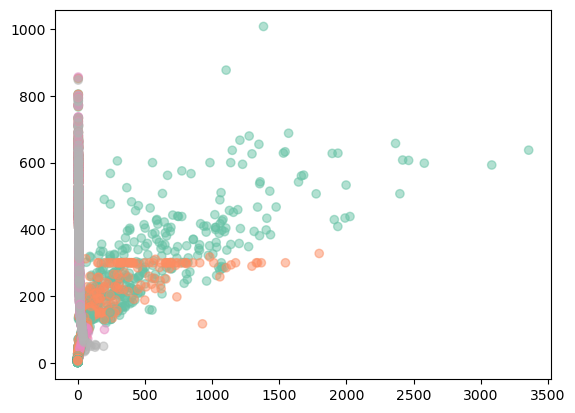

In [38]:
fig, ax = plt.subplots()
ax.scatter(results["init_translation_r"], results["elongation_r"], c=results["dt"],cmap="Set2", alpha=0.5)
# ax.set_xlim(-2,6)
# ax.set_ylim(-1,50)

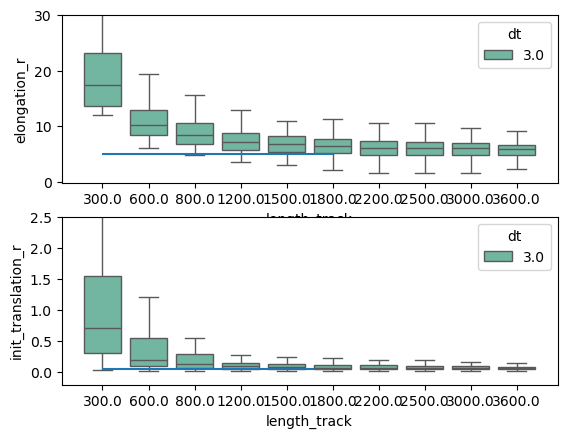

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [46]:
import seaborn as sns
results = pd.read_csv(os.path.join("/mnt/sda1/Sophie/2-KineticAnalysisData/2-Datas/05-Modelling/01-TrackLength", 
                                   "result_track_length_translation_rate_5_same_exact.csv"), index_col="Unnamed: 0")

results_crop = results[(results["length_track"]>60) & (results["dt"]==3.0)]

fig, axes = plt.subplots(nrows=2)
sns.boxplot(x="length_track", y="elongation_r", hue="dt", data=results_crop, palette="Set2", showfliers=False, ax = axes[0])
axes[0].set_ylim(-0.2, 30)
axes[0].hlines(elongation_rate, 0.0, 5)

sns.boxplot(x="length_track", y="init_translation_r", hue="dt", data=results_crop, palette="Set2", showfliers=False, ax = axes[1])
axes[1].set_ylim(-0.2, 2.5)
axes[1].hlines(0.05, 0.0, 5)

# fig.set_size_inches(2.37*2,6.21)
plt.show()
fig.savefig(os.path.join(path_save, "NEW_track_length_dt_v2_group_length_5aasec_200rep_epitope_same_dt3_exact.eps"), dpi=300)

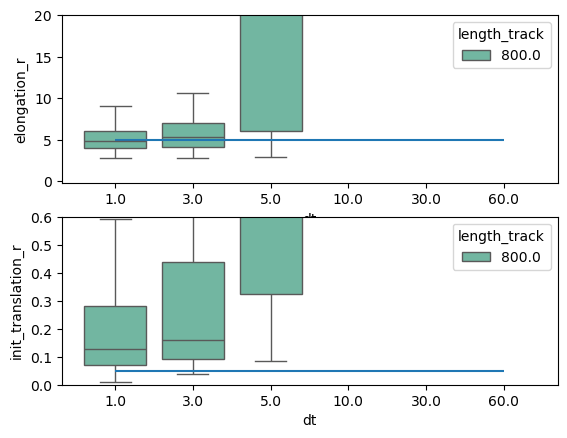

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


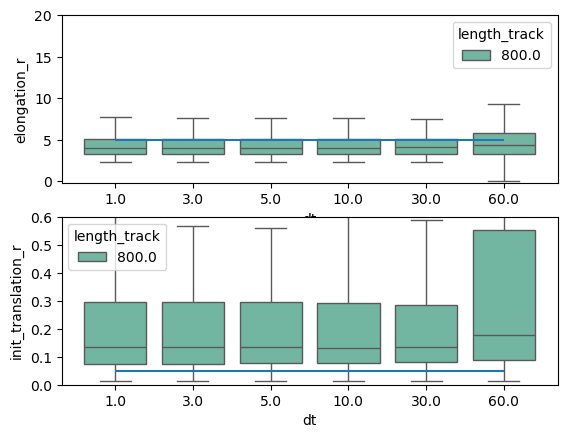

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


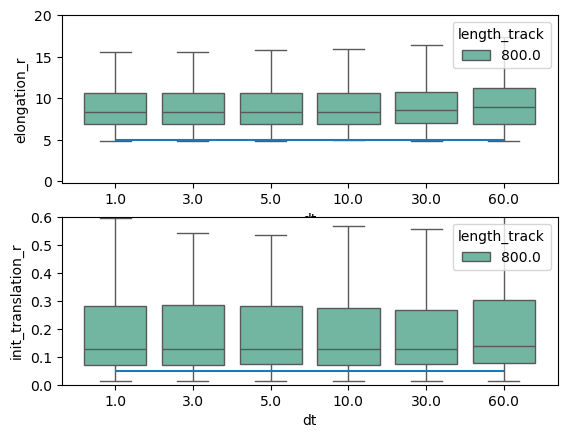

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [72]:
import seaborn as sns

for t in ["approx", "epitope", "exact"]:
    
    results = pd.read_csv(os.path.join("/mnt/sda1/Sophie/2-KineticAnalysisData/2-Datas/05-Modelling/01-TrackLength", 
                                       "result_track_length_translation_rate_5_same_"+t+".csv"), index_col="Unnamed: 0")
    
    results_crop = results[(results["length_track"]==800)]
    
    fig, axes = plt.subplots(nrows=2)
    sns.boxplot(x="dt", y="elongation_r", hue="length_track", data=results_crop, palette="Set2", showfliers=False, ax = axes[0])
    axes[0].set_ylim(-0.2, 20)
    axes[0].hlines(elongation_rate, 0.0, 5)
    
    sns.boxplot(x="dt", y="init_translation_r", hue="length_track", data=results_crop, palette="Set2", showfliers=False, ax = axes[1])
    axes[1].set_ylim(0, 0.6)
    axes[1].hlines(0.05, 0.0, 5)
    
    # fig.set_size_inches(2.37*2,6.21)
    plt.show()
    fig.savefig(os.path.join(path_save, "NEW_track_length_dt_v2_group_length_5aasec_200rep_epitope_same_track800"+t+"_2.eps"), dpi=300)

In [39]:
print("done")

done


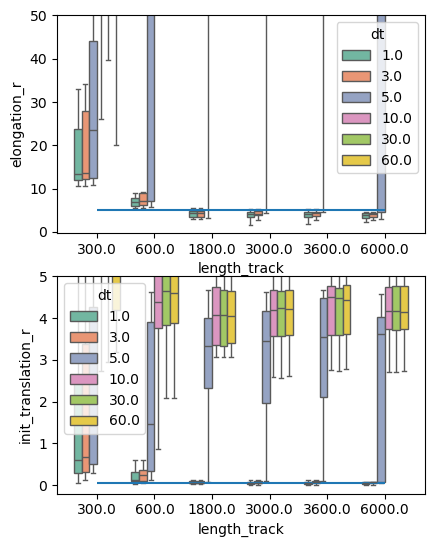

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [65]:
results = pd.read_csv(os.path.join(path, "results_dt_track_length_translation_rate_5_nb_point_approx.csv"), index_col="Unnamed: 0")
import seaborn as sns
results_crop = results[results["length_track"]>60]

fig, axes = plt.subplots(nrows=2)
sns.boxplot(x="length_track", y="elongation_r", hue="dt", data=results_crop, palette="Set2", showfliers=False, ax = axes[0])
axes[0].set_ylim(-0.2, 50)
axes[0].hlines(elongation_rate, 0.0, 5)

sns.boxplot(x="length_track", y="init_translation_r", hue="dt", data=results_crop, palette="Set2", showfliers=False, ax = axes[1])
axes[1].set_ylim(-0.2, 5)
axes[1].hlines(0.05, 0.0, 5)

fig.set_size_inches(2.37*2,6.21)
plt.show()
fig.savefig(os.path.join(path_save, "track_length_dt_v2_group_length_5aasec_20rep_approx.eps"), dpi=300)

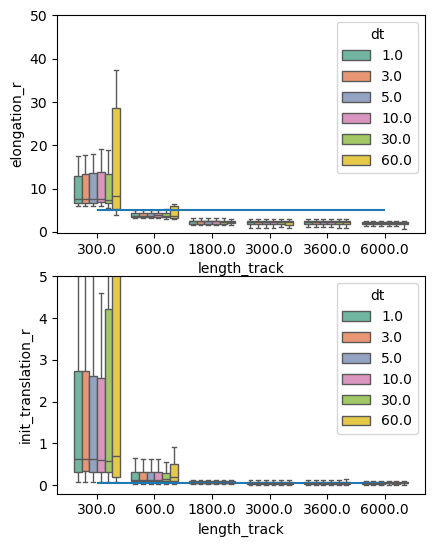

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [66]:
results = pd.read_csv(os.path.join(path, "results_dt_track_length_translation_rate_5_nb_point_epitope.csv"), index_col="Unnamed: 0")
import seaborn as sns
results_crop = results[results["length_track"]>60]

fig, axes = plt.subplots(nrows=2)
sns.boxplot(x="length_track", y="elongation_r", hue="dt", data=results_crop, palette="Set2", showfliers=False, ax = axes[0])
axes[0].set_ylim(-0.2, 50)
axes[0].hlines(elongation_rate, 0.0, 5)

sns.boxplot(x="length_track", y="init_translation_r", hue="dt", data=results_crop, palette="Set2", showfliers=False, ax = axes[1])
axes[1].set_ylim(-0.2, 5)
axes[1].hlines(0.05, 0.0, 5)

fig.set_size_inches(2.37*2,6.21)
plt.show()
fig.savefig(os.path.join(path_save, "track_length_dt_v2_group_length_5aasec_20rep_epitope.eps"), dpi=300)

In [46]:
pd.crosstab(results["length_track"], results["dt"], values=results["elongation_r"], aggfunc="mean")

dt,1.0,3.0,5.0,10.0,30.0,60.0
length_track,,,,,,
60.0,116.932962,268.568299,133.706476,493.768942,NaN,NaN
300.0,41.152341,41.107069,41.135659,40.916417,57.084075,109.571650
600.0,30.450503,30.551994,30.420268,30.598532,37.163794,78.641216
1800.0,25.460558,25.528780,25.405919,25.303151,26.123839,38.011440
3000.0,26.307416,26.345032,26.261554,26.167770,26.588210,24.549357
3600.0,25.828416,25.859569,25.815093,25.649836,26.206891,24.431090
6000.0,21.462904,21.555712,21.559523,21.255523,20.493873,18.545753


In [47]:
pd.crosstab(results["length_track"], results["dt"], values=results["init_translation_r"], aggfunc="mean")

dt,1.0,3.0,5.0,10.0,30.0,60.0
length_track,,,,,,
60.0,1.781709,1.895700,1.946880,4.724208,NaN,NaN
300.0,0.143542,0.142770,0.146505,0.151047,0.158079,0.549466
600.0,0.068426,0.068393,0.068699,0.070231,0.076603,0.181816
1800.0,0.052213,0.052255,0.052161,0.052133,0.053103,0.072425
3000.0,0.053698,0.053696,0.053609,0.053537,0.054461,0.049701
3600.0,0.054329,0.054280,0.054211,0.053955,0.054649,0.050554
6000.0,0.040741,0.040870,0.040868,0.040165,0.038604,0.031005


In [ ]:
import seaborn as sns

fig, axes = plt.subplots(nrows=2)
sns.boxplot(x="long_track", y="elongation_r", hue="dt", data=results, palette="Set1", showfliers=False, ax = axes[0])
# axes[0].set_ylim(-0.2, 50)
axes[0].hlines(elongation_rate, 0.0, 7)

sns.boxplot(x="long_track", y="init_translation_r", hue="dt", data=results, palette="Set1", showfliers=False, ax = axes[1])
# axes[1].set_ylim(-0.2, 1)
axes[1].hlines(0.05, 0.0, 7)

fig.set_size_inches(10,10)
plt.show()
# fig.savefig(os.path.join(path_save, "track_length_dt_v2.eps"), dpi=300)

In [ ]:
results[(results.dt == 60.0) & (results.long_track >1000) & (results.elongation_r>0)]

In [ ]:
results_group = results.groupby(["dt", "long_track"]).mean()
results_group.reset_index(inplace=True)

elongation_ref = 24

results_group["elongation_r_diff"] = elongation_ref-results_group['elongation_r']
results_group["elongation_r_ratio"] = 100*results_group["elongation_r"]/elongation_ref - 100
results_group["elongation_r_ratio"]= np.abs(results_group["elongation_r_ratio"])


results_group["init_translation_r_diff"] = 20-results_group['init_translation_r']
results_group["init_translation_r_ratio"] = 100*results_group["init_translation_r"]/20 -100
results_group["init_translation_r_ratio"] = np.abs(results_group["init_translation_r_ratio"])

results_group

In [ ]:
import seaborn as sns
from matplotlib.colors import ListedColormap
# Create a symmetric colormap
color = plt.cm.coolwarm
color_r = plt.cm.coolwarm_r
combined_colors = ListedColormap(color_r(np.linspace(0, 1, 128)).tolist() +
                                 color(np.linspace(0, 1, 128)).tolist())

heatmap_data = results_group.pivot(index='long_track', columns='dt', values='elongation_r_ratio')

# Create the heatmap
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 6))
# plt.figure(figsize=(8, 6))
ax1 = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap="PiYG_r",
                 vmin = 0,
                 vmax = 100,
                 ax=ax1)
# Invert the y-axis
ax1.invert_yaxis()
ax1.set_title("Heatmap of elongation rate Values")
ax1.set_xlabel("time step")
ax1.set_ylabel("track length")



heatmap_data = results_group.pivot(index='long_track', columns='dt', values='init_translation_r_ratio')
ax2 = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap="PiYG_r",
                 vmin = 0,
                 vmax = 100, 
                  ax = ax2
                )
# Invert the y-axis
ax2.invert_yaxis()
ax2.set_title("Heatmap of initiation rate Values")
ax2.set_xlabel("time step")
ax2.set_ylabel("track length")

In [ ]:
import seaborn as sns
from matplotlib.colors import ListedColormap
# Create a symmetric colormap
color = plt.cm.coolwarm
color_r = plt.cm.coolwarm_r
combined_colors = ListedColormap(color_r(np.linspace(0, 1, 128)).tolist() +
                                 color(np.linspace(0, 1, 128)).tolist())

heatmap_data = results_group.pivot(index='long_track', columns='dt', values='init_translation_r_ratio')

# Create the heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap=combined_colors,
                 vmin = 0,
                 vmax = 200
                )
# Invert the y-axis
ax.invert_yaxis()

plt.title("Heatmap of initiation rate Values")
plt.xlabel("time step")
plt.ylabel("track length")
plt.show()

# Display G(tau) for different track length

33 32
3.1840355602458876 2.154525151678292 248.74094054993458 2.154525151678292 [None, None]


(-0.1, 0.2)

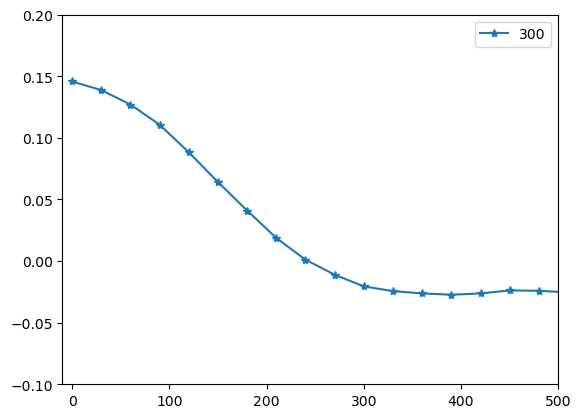

In [24]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["similar_prot"]

fig, ax = plt.subplots()
#[1, 5, 10, 30, 50, 60, 100] in min
# in sec
for length_track in [2200]:
    #for t in [30]:
    # for t in [10,30,50,100, 300, 600]:
    for t in [300]:
        dt = t*0.1
        nb_point = int(length_track/dt)
        i=10
        datas2 = datas[datas["TRACK_ID"]==i][::t][:nb_point]
        datas2["FRAME"] = np.arange(nb_point)
        if (len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 2):
            
            (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                   i,
                                                   normalise_intensity=1,
                                                   delta_t=dt,
                                                   rtol=1e-1,
                                                   nb_missing_point=0,
                                                   )

            
            (x_auto, y_auto, k, c,elongation_r, translation_init_r,perr) = single_track_analysis(x, 
                                                                                                 y, 
                                                                                                 delta_t = dt,
                                                                                                 protein_size=prot_aa_size["similar_prot"],
                                                                                                 suntag_size =prot_aa_size["32xsuntag"], 
                                                                                                 repetition_suntag = 32,
                                                                                                 mm=None,
                                                                                                 # method="exact",
                                                                                                 method="approx",
                                                                                                 # method="epitope",
                                                                                                 simulation=True)

            
            print(k, c,elongation_r, translation_init_r,perr)
            ax.plot(x_auto, y_auto, '-*',label=t)            
            from kineticanalysis.analysis.fit_functions import function_approx, function_exact
            N = 32
            M = 32
            # y_fit = function_exact(x_auto, k, c, N, M)
            y_fit = function_approx(x_auto, k, c)
            # ax.plot(x_auto,
                    # y_fit[:len(y_auto)],c='grey')
            # ax.plot(x_auto, y_auto, label=length_track)

ax.legend()
ax.set_xlim(-10,500)
ax.set_ylim(-0.1,0.2)
# fig.savefig("gtau_dt_crop_2200.eps")

In [25]:
def fit_autocorrelation_approx_v2(x, y, method='lm'):
    """
    Fit autocorrelation curve with func_
    Parameters
    ----------
    x, y: x and y values of autocorrelation curve
    method : method of fit resolution
    """

    # popt, pcov = optimize.curve_fit(function_approx,
    #                                 x,
    #                                 y,
    #                                 method=method)
    model = lmfit.Model(function_approx)
    params = lmfit.Parameters()
    params.add('t', value=np.float128(0.6), min=0)
    params.add('c', value=np.float128(0.1), min=0)
    result = model.fit(y, params, x=x, nan_policy='raise')
    return (result.params["t"].value, result.params["c"].value,
            [result.params["t"].stderr, result.params["c"].stderr])
    # elongation_r = protein_size / popt[0]
    # translation_init_r = 1 / popt[1]
    # return elongation_r, translation_init_r, np.sqrt(np.diag(pcov))
    # return popt[0], popt[1], np.sqrt(np.diag(pcov))


def fit_autocorrelation_approx_v1(x, y, method='lm'):
    """
    Fit autocorrelation curve with func_
    Parameters
    ----------
    x, y: x and y values of autocorrelation curve
    method : method of fit resolution
    """

    popt, pcov = optimize.curve_fit(function_approx,
                                    x,
                                    y,
                                    method=method)
    
    return popt[0], popt[1], np.sqrt(np.diag(pcov))

In [26]:
import multipletau
import lmfit

import numpy as np

from scipy import optimize

print(fit_autocorrelation_approx_v1(x_auto,y_auto))
print(fit_autocorrelation_approx_v2(x_auto,y_auto))

(2.5879980332377284, 2.650730254917458, array([inf, inf]))
(3.1840355602458876, 2.154525151678292, [None, None])


/tmp/ipykernel_758282/1279895691.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,


In [27]:
M = 800/24
print(M/2.58*24, M/3.18*24)

310.07751937984494 251.57232704402517


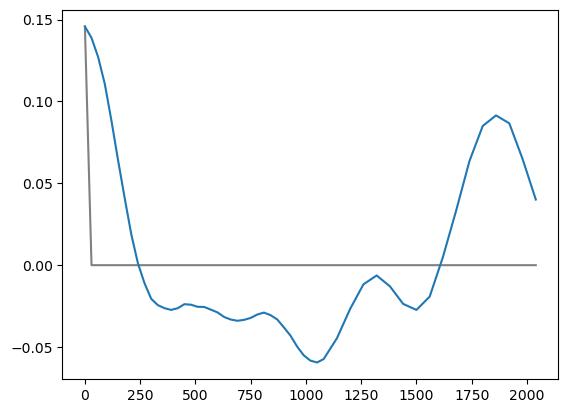

In [28]:
fig, ax = plt.subplots()
y_fit = function_approx(x_auto, k, c)

ax.plot(x_auto,
        y_fit[:len(y_auto)],c='grey')
ax.plot(x_auto, y_auto, label=length_track)